In [2]:
from PIL import Image # for read image file
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("nikita_kirkified.jpg")
arr = np.asarray(img)

print(arr.shape)
print(arr.dtype)

#print(arr[943,1001])
#print(arr.shape[0])
#print(arr.shape[1])

(944, 1002, 3)
uint8


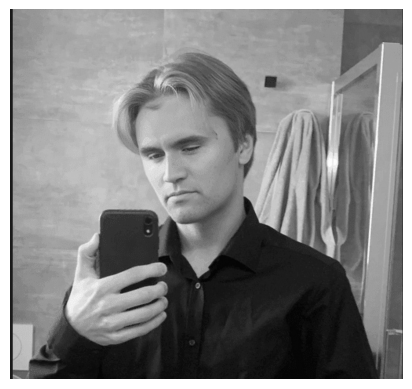

In [4]:
# arr[:, :, N] means to take all rows and columns and N is the channel for RGB R-0, G-1, B-2
R = arr[:, :, 0] # all red
G = arr[:, :, 1] # all green
B = arr[:, :, 2] # all blue

# 0.299,0.587,0.114 are luma weights, basically to a human eye red, green and blue do not appear equally
# so these weight are basically show which aspects colors human eye is most sensitive to
gray = R*0.299+G*0.587+B*0.114
gray = gray.astype(np.uint8)

# using matplotlib render the same image in gray scale basically
# also cmap which is colormap indicates plt to use shades of gray otherwise it would try to colorize it
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

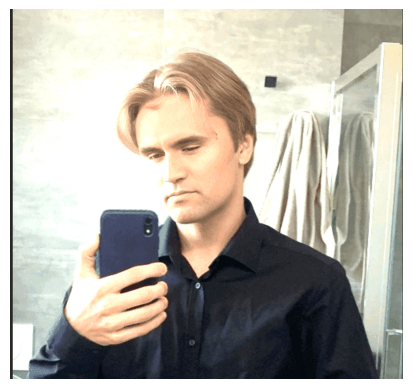

In [5]:
# for making the image brighter just multiply each number in the array by some value that is more than 1
# so to darken multiply by something between 0 and 1
bright = arr * 1.5
# this is needed just because some values might exceed 255 which is the maximum for 8 byte so everyting over 255 gets brought down to just 255
bright = np.clip(bright, 0, 255).astype(np.uint8)

plt.imshow(bright) # no gray scale cuz we are showing the initial image
plt.axis('off')
plt.show()

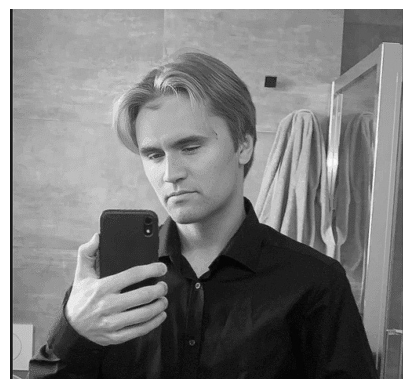

In [6]:
def convolve2d(image, kernel):
    kh, kw = kernel.shape # kernel dimensions (3x3 in this case)
    pad = kh // 2 # the padding, basically the padding between the center of a kernel and the pixels outside of kernel, in this case 1

    # creating a padded image cuz when processing pixel at (0,0) kernel will take in border values which dont exist
    # mode=edge basically fills the border values needed by repeating outermost pixels
    padded = np.pad(image, pad, mode='edge') 
    output = np.zeros_like(image, dtype=np.float64) # output image, zeros_like means that the image (an array) starts at zeros, this is the output that is being written in the for loop below

    # loop through each pixel and process it through kernel then sum to output image (an array)
    # patch = 3x3 block from padded image
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+kh, j:j+kw] # the 3x3 block of original pixel values from padded image
            output[i, j] = np.sum(patch * kernel) # assign sum all 9 values produced from multiplying patch (3x3 original image values) by kernel (hardcoded values in this case) to pixel coordinate value

    return np.clip(output, 0, 255).astype(np.uint8) # ofcourse normalizee so values are in 0 to 255 range

# the kernel thats being used in this case is to sharpen the image
# basically to increase differences between center pixels and it's neighbours
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float64)

# produce sharpened image
sharpened = convolve2d(gray, sharpen_kernel)

# show bruh
plt.imshow(sharpened, cmap='gray')
plt.axis('off')
plt.show()